# 11 -- SSM/MoE Gradient Balance

**Goal**: Investigate and fix the SSM/MoE gradient imbalance discovered in NB09
(SSM layers receive ~27x less gradient than MoE layers, ratio=0.037).

Experiments:
1. **Baseline gradient profile** -- per-layer gradient norms, SSM vs MoE distribution
2. **Per-component learning rates** -- uniform vs SSM 10x boost vs SSM 30x boost
3. **Gradient scaling** -- post-backward SSM gradient multiplication (10x, 30x)
4. **LayerNorm placement** -- extra LayerNorm before SSM blocks for gradient flow
5. **Summary comparison table** -- final_kl, agreement, gradient norms, ratio

Wayy Research, 2024-2026.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
sys.path.insert(0, str(Path.cwd().parent.parent / "aetheris"))

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 120
import json
import time
import copy
from collections import defaultdict
from dataclasses import dataclass

from aetheris import AetherisConfig, HybridMambaMoE
from aetheris.modules.ssm import SSMBlock
from aetheris.modules.moe import SparseMoELayer
from aya_distill.distill.cka import linear_cka

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cpu")
Path("../results").mkdir(exist_ok=True)

print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

# --- Global constants ---
VOCAB_SIZE = 5000
SEQ_LEN = 32
BATCH_SIZE = 4
N_STEPS = 200
TEACHER_D_MODEL = 256
TEACHER_LAYERS = 4

all_results = {}  # Collect everything for JSON export

Device: cpu
PyTorch: 2.10.0+cu128


## 1. Synthetic Teacher + Utilities

Same teacher as NB09: `nn.TransformerEncoder` with d_model=256, 4 layers, V=5000.
Pre-trained briefly so it has non-trivial output distributions.

In [2]:
class SyntheticTeacher(nn.Module):
    """Lightweight transformer teacher for distillation experiments."""
    def __init__(self, vocab_size: int, d_model: int, n_layers: int, nhead: int = 8):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=0.0, batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.embedding.weight  # weight tying
        nn.init.normal_(self.embedding.weight, mean=0.0, std=0.02)
        self._causal_mask = None

    def _get_causal_mask(self, seq_len: int, device: torch.device) -> torch.Tensor:
        if self._causal_mask is None or self._causal_mask.shape[0] != seq_len:
            self._causal_mask = nn.Transformer.generate_square_subsequent_mask(
                seq_len, device=device
            )
        return self._causal_mask

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        x = self.embedding(input_ids)
        mask = self._get_causal_mask(input_ids.shape[1], input_ids.device)
        x = self.encoder(x, mask=mask, is_causal=True)
        return self.lm_head(x)


# Build and pre-train teacher
torch.manual_seed(42)
teacher = SyntheticTeacher(VOCAB_SIZE, TEACHER_D_MODEL, TEACHER_LAYERS, nhead=8)
t_params = sum(p.numel() for p in teacher.parameters())

t_optimizer = torch.optim.AdamW(teacher.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

print(f"Pre-training teacher ({t_params/1e6:.1f}M params) on random tokens...")
teacher.train()
for step in range(100):
    ids = torch.randint(0, VOCAB_SIZE, (BATCH_SIZE, SEQ_LEN))
    logits = teacher(ids)
    loss = loss_fn(logits[:, :-1].reshape(-1, VOCAB_SIZE), ids[:, 1:].reshape(-1))
    t_optimizer.zero_grad()
    loss.backward()
    t_optimizer.step()
    if step % 25 == 0:
        print(f"  Step {step}: loss={loss.item():.4f}")

teacher.eval()
for p in teacher.parameters():
    p.requires_grad = False
print(f"Teacher ready: {t_params/1e6:.1f}M params, {TEACHER_LAYERS} layers, d={TEACHER_D_MODEL}")


# --- Helper functions ---
def make_student(d_model: int = 128, n_layer: int = 4, num_experts: int = 2,
                 d_ff: int = 384) -> HybridMambaMoE:
    """Create a student model with given config."""
    cfg = AetherisConfig(
        vocab_size=VOCAB_SIZE,
        d_model=d_model,
        n_layer=n_layer,
        num_experts=num_experts,
        top_k=1,
        d_ff=d_ff,
        ssm_d_state=8,
        ssm_expand=2,
        max_seq_len=SEQ_LEN,
        gradient_checkpointing=False,
        dtype="float32",
    )
    return HybridMambaMoE(cfg)


def smooth(arr, window=15):
    """Simple moving average."""
    if len(arr) < window:
        return arr
    return np.convolve(arr, np.ones(window)/window, mode='valid')


def collect_per_layer_grads(student: HybridMambaMoE):
    """Collect gradient norms for every individual layer."""
    layer_grads = {}
    # Embedding
    if student.embedding.weight.grad is not None:
        layer_grads["embedding"] = student.embedding.weight.grad.norm().item()
    # Per-layer
    for idx, layer in enumerate(student.layers):
        layer_type = "ssm" if isinstance(layer, SSMBlock) else "moe"
        total_norm = 0.0
        count = 0
        for p in layer.parameters():
            if p.grad is not None:
                total_norm += p.grad.norm().item()
                count += 1
        layer_grads[f"layer{idx}_{layer_type}"] = total_norm / max(count, 1)
    # lm_head (tied with embedding)
    if student.lm_head.weight.grad is not None:
        layer_grads["lm_head"] = student.lm_head.weight.grad.norm().item()
    return layer_grads


def compute_distill_loss(student, teacher_model, input_ids, labels, temperature=2.0, alpha=0.7):
    """Compute distillation loss and return (total_loss, kl_loss, ce_loss, aux_loss, student_logits, teacher_logits)."""
    with torch.no_grad():
        teacher_logits = teacher_model(input_ids)

    output = student(input_ids, labels=labels)
    student_logits = output["logits"]
    ce_loss = output["ce_loss"]
    aux_loss = output["aux_loss"]

    t_shift = teacher_logits[:, :-1, :].contiguous()
    s_shift = student_logits[:, :-1, :].contiguous()

    t_log_probs = F.log_softmax(t_shift / temperature, dim=-1)
    s_log_probs = F.log_softmax(s_shift / temperature, dim=-1)

    kl_loss = F.kl_div(
        s_log_probs.view(-1, VOCAB_SIZE),
        t_log_probs.view(-1, VOCAB_SIZE),
        log_target=True,
        reduction="batchmean",
    ) * (temperature ** 2)

    total_loss = alpha * kl_loss + (1 - alpha) * ce_loss + 0.01 * aux_loss
    return total_loss, kl_loss, ce_loss, aux_loss, student_logits, teacher_logits


def evaluate_student(student, teacher_model, temperature=2.0, n_eval=5):
    """Evaluate final KL and agreement."""
    student.eval()
    kl_vals, agree_vals = [], []
    with torch.no_grad():
        for _ in range(n_eval):
            ids = torch.randint(0, VOCAB_SIZE, (BATCH_SIZE, SEQ_LEN))
            t_logits = teacher_model(ids)
            s_logits = student(ids)["logits"]
            t_lp = F.log_softmax(t_logits / temperature, dim=-1)
            s_lp = F.log_softmax(s_logits / temperature, dim=-1)
            kl_val = F.kl_div(
                s_lp.view(-1, VOCAB_SIZE), t_lp.view(-1, VOCAB_SIZE),
                log_target=True, reduction="batchmean",
            ).item() * (temperature ** 2)
            kl_vals.append(kl_val)
            agree = (t_logits.argmax(-1) == s_logits.argmax(-1)).float().mean().item()
            agree_vals.append(agree)
    return float(np.mean(kl_vals)), float(np.mean(agree_vals))


print("Utilities ready.")

/tmp/ipykernel_379903/911551843.py:10: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


Pre-training teacher (4.4M params) on random tokens...
  Step 0: loss=8.5465


  Step 25: loss=8.6325


  Step 50: loss=8.5281


  Step 75: loss=8.6528


Teacher ready: 4.4M params, 4 layers, d=256
Utilities ready.


## 2. Experiment 1: Baseline Gradient Profile

Train default student (d=128, 4 layers) and track per-layer gradient norms for ALL
individual layers. This gives us the full picture of the SSM vs MoE gradient distribution
that NB09 identified (ratio ~0.037).

=== Experiment 1: Baseline Gradient Profile ===
Student: 1.44M params, 4 layers (SSM@0,2 / MoE@1,3)



Per-layer gradient norms (mean over training):
  embedding           : mean=0.393521, std=0.019544
  layer0_ssm          : mean=0.003386, std=0.000324
  layer1_moe          : mean=0.061008, std=0.007362
  layer2_ssm          : mean=0.000715, std=0.000085
  layer3_moe          : mean=0.045783, std=0.004170
  lm_head             : mean=0.393521, std=0.019544

SSM mean grad: 0.002051
MoE mean grad: 0.053396
SSM/MoE ratio: 0.0384 (1.0 = parity)
MoE receives 26.0x more gradient than SSM

Baseline final: KL=0.0703, agreement=0.9%


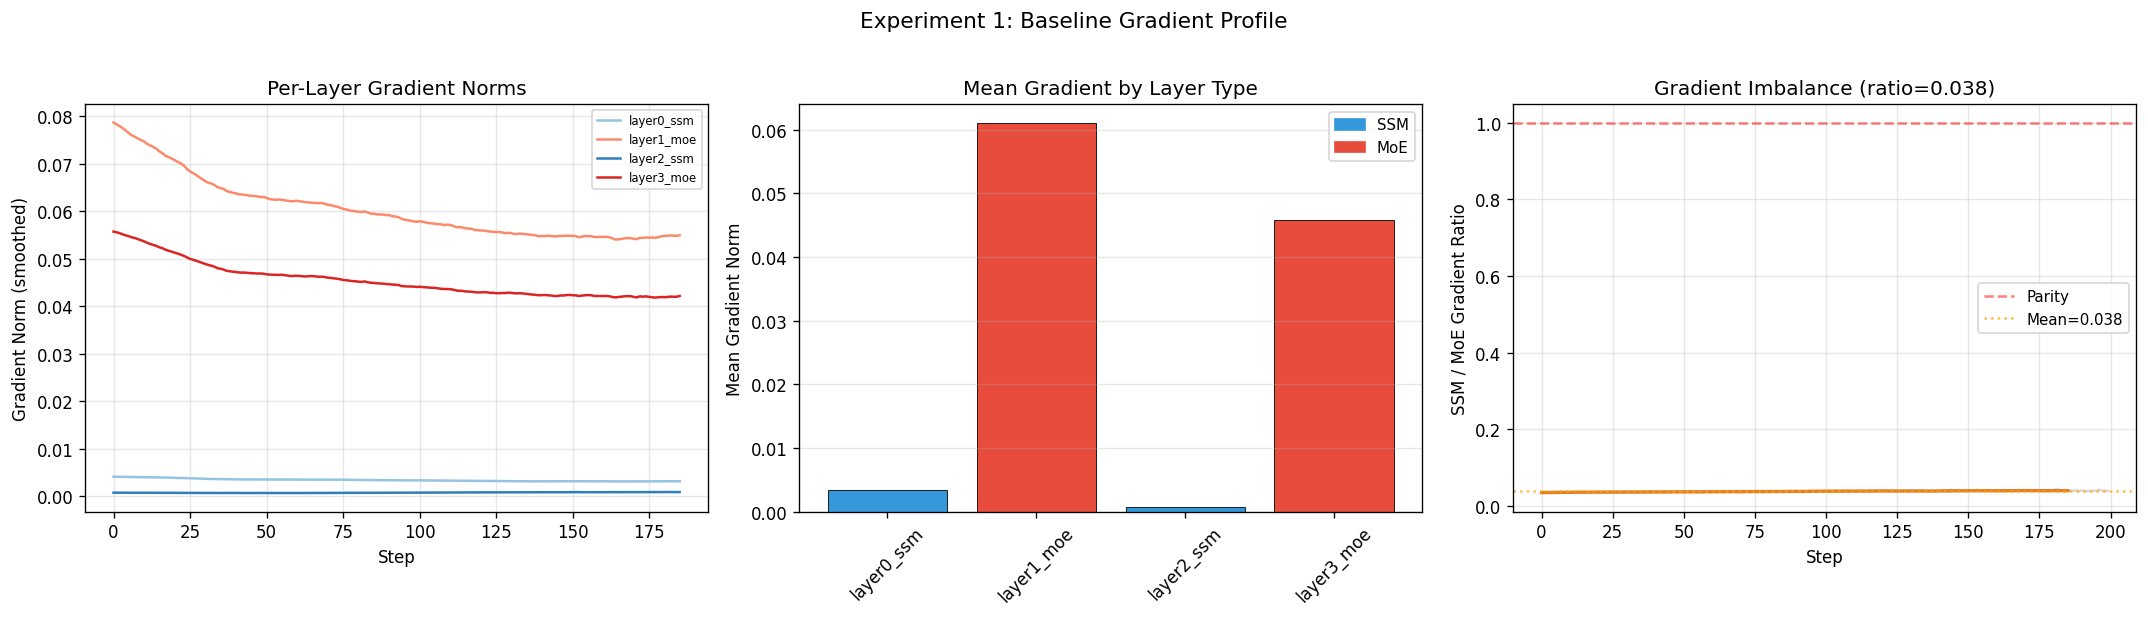

Saved: results/11_gradient_profiles.png


In [3]:
print("=== Experiment 1: Baseline Gradient Profile ===")
torch.manual_seed(42)
student_baseline = make_student(d_model=128, n_layer=4)
s_params = sum(p.numel() for p in student_baseline.parameters())
print(f"Student: {s_params/1e6:.2f}M params, 4 layers (SSM@0,2 / MoE@1,3)")

optimizer_bl = torch.optim.AdamW(student_baseline.parameters(), lr=3e-4, weight_decay=0.01)
scheduler_bl = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_bl, T_max=N_STEPS)

# Track per-layer gradient norms at every step
baseline_grad_history = defaultdict(list)  # key -> list of norms
baseline_kl_history = []
baseline_agree_history = []

student_baseline.train()
for step in range(N_STEPS):
    input_ids = torch.randint(0, VOCAB_SIZE, (BATCH_SIZE, SEQ_LEN))
    labels = input_ids.clone()

    total_loss, kl_loss, ce_loss, aux_loss, s_logits, t_logits = compute_distill_loss(
        student_baseline, teacher, input_ids, labels
    )

    optimizer_bl.zero_grad()
    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(student_baseline.parameters(), 1.0)

    # Collect per-layer grads
    grads = collect_per_layer_grads(student_baseline)
    for k, v in grads.items():
        baseline_grad_history[k].append(v)

    optimizer_bl.step()
    scheduler_bl.step()
    baseline_kl_history.append(kl_loss.item())

    if step % 10 == 0:
        with torch.no_grad():
            agree = (t_logits.argmax(-1) == s_logits.argmax(-1)).float().mean().item()
        baseline_agree_history.append(agree)

# Compute summary stats
print("\nPer-layer gradient norms (mean over training):")
ssm_means, moe_means = [], []
for k in sorted(baseline_grad_history.keys()):
    vals = baseline_grad_history[k]
    mean_val = np.mean(vals)
    print(f"  {k:20s}: mean={mean_val:.6f}, std={np.std(vals):.6f}")
    if "ssm" in k:
        ssm_means.append(mean_val)
    elif "moe" in k:
        moe_means.append(mean_val)

ssm_avg = np.mean(ssm_means)
moe_avg = np.mean(moe_means)
ratio = ssm_avg / (moe_avg + 1e-10)
print(f"\nSSM mean grad: {ssm_avg:.6f}")
print(f"MoE mean grad: {moe_avg:.6f}")
print(f"SSM/MoE ratio: {ratio:.4f} (1.0 = parity)")
print(f"MoE receives {1/ratio:.1f}x more gradient than SSM")

final_kl_bl, final_agree_bl = evaluate_student(student_baseline, teacher)
print(f"\nBaseline final: KL={final_kl_bl:.4f}, agreement={final_agree_bl*100:.1f}%")

all_results["baseline"] = {
    "final_kl": final_kl_bl,
    "final_agreement": final_agree_bl,
    "ssm_grad_mean": round(ssm_avg, 6),
    "moe_grad_mean": round(moe_avg, 6),
    "ratio": round(ratio, 4),
}

# --- Plot: gradient profiles ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Per-layer gradient norms over training
ax = axes[0]
cmap_ssm = plt.cm.Blues
cmap_moe = plt.cm.Reds
ssm_idx, moe_idx = 0, 0
for k in sorted(baseline_grad_history.keys()):
    if k in ("embedding", "lm_head"):
        continue
    vals = baseline_grad_history[k]
    if "ssm" in k:
        color = cmap_ssm(0.4 + ssm_idx * 0.3)
        ssm_idx += 1
    else:
        color = cmap_moe(0.4 + moe_idx * 0.3)
        moe_idx += 1
    ax.plot(smooth(vals), label=k, color=color, linewidth=1.5)
ax.set_xlabel("Step")
ax.set_ylabel("Gradient Norm (smoothed)")
ax.set_title("Per-Layer Gradient Norms")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# (b) Bar chart: mean gradient norm by layer
ax = axes[1]
layer_names = sorted([k for k in baseline_grad_history.keys() if k not in ("embedding", "lm_head")])
layer_means = [np.mean(baseline_grad_history[k]) for k in layer_names]
colors_bar = ["#3498db" if "ssm" in k else "#e74c3c" for k in layer_names]
bars = ax.bar(layer_names, layer_means, color=colors_bar, edgecolor="black", linewidth=0.5)
ax.set_ylabel("Mean Gradient Norm")
ax.set_title("Mean Gradient by Layer Type")
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis="y")
# Add legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#3498db", label="SSM"), Patch(color="#e74c3c", label="MoE")], fontsize=9)

# (c) SSM/MoE ratio over training
ax = axes[2]
ssm_keys = sorted([k for k in baseline_grad_history if "ssm" in k])
moe_keys = sorted([k for k in baseline_grad_history if "moe" in k])
ssm_total = np.mean([baseline_grad_history[k] for k in ssm_keys], axis=0)
moe_total = np.mean([baseline_grad_history[k] for k in moe_keys], axis=0)
ratio_trace = ssm_total / (moe_total + 1e-10)
ax.plot(ratio_trace, alpha=0.3, color="gray")
ax.plot(smooth(ratio_trace), color="#e67e22", linewidth=2)
ax.axhline(1.0, color="red", linestyle="--", alpha=0.5, label="Parity")
ax.axhline(ratio, color="orange", linestyle=":", alpha=0.7, label=f"Mean={ratio:.3f}")
ax.set_xlabel("Step")
ax.set_ylabel("SSM / MoE Gradient Ratio")
ax.set_title(f"Gradient Imbalance (ratio={ratio:.3f})")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle("Experiment 1: Baseline Gradient Profile", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../results/11_gradient_profiles.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: results/11_gradient_profiles.png")

## 3. Experiment 2: Per-Component Learning Rates

Test three LR strategies using `torch.optim.AdamW` with param groups:
- **Uniform**: all params at lr=3e-4 (same as baseline)
- **SSM 10x boost**: SSM params get lr=3e-3, rest get lr=3e-4
- **SSM 30x boost**: SSM params get lr=9e-3, rest get lr=3e-4

The hypothesis: giving SSM layers a higher LR compensates for their lower gradient magnitude.

=== Experiment 2: Per-Component Learning Rates ===


  uniform_3e-4    | KL=0.0703 | agree=0.9% | SSM_grad=0.002051 | MoE_grad=0.053396 | ratio=0.0384 | 13.8s


  ssm_10x         | KL=0.0524 | agree=10.9% | SSM_grad=0.015072 | MoE_grad=0.024963 | ratio=0.6038 | 11.4s


  ssm_30x         | KL=0.0516 | agree=9.1% | SSM_grad=0.012991 | MoE_grad=0.009604 | ratio=1.3526 | 11.3s


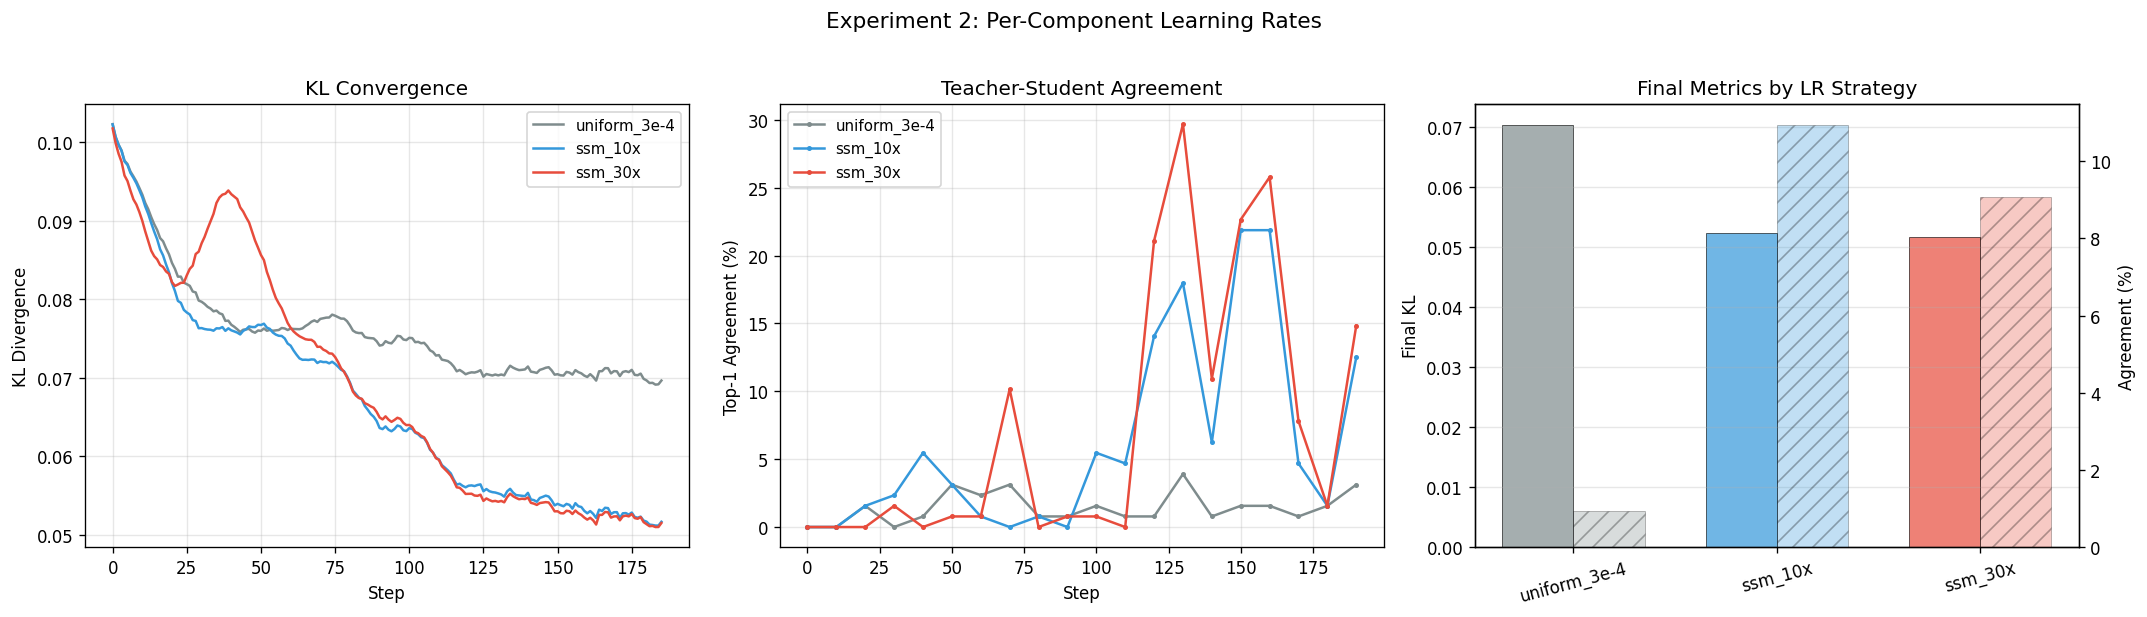

Saved: results/11_lr_strategies.png


In [4]:
def train_with_lr_strategy(strategy_name, ssm_lr, base_lr=3e-4, seed=42):
    """Train a student with per-component LR and track metrics."""
    torch.manual_seed(seed)
    student = make_student(d_model=128, n_layer=4)
    student.train()

    # Build param groups
    ssm_params = []
    other_params = []
    for name, param in student.named_parameters():
        is_ssm = False
        for idx, layer in enumerate(student.layers):
            if isinstance(layer, SSMBlock):
                for pname, p in layer.named_parameters():
                    if p is param:
                        is_ssm = True
                        break
            if is_ssm:
                break
        if is_ssm:
            ssm_params.append(param)
        else:
            other_params.append(param)

    param_groups = [
        {"params": ssm_params, "lr": ssm_lr},
        {"params": other_params, "lr": base_lr},
    ]
    optimizer = torch.optim.AdamW(param_groups, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_STEPS)

    kl_history = []
    agree_history = []
    grad_ssm_history = []
    grad_moe_history = []

    for step in range(N_STEPS):
        input_ids = torch.randint(0, VOCAB_SIZE, (BATCH_SIZE, SEQ_LEN))
        labels = input_ids.clone()

        total_loss, kl_loss, ce_loss, aux_loss, s_logits, t_logits = compute_distill_loss(
            student, teacher, input_ids, labels
        )

        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)

        # Track SSM and MoE grad norms
        ssm_norms, moe_norms = [], []
        for idx, layer in enumerate(student.layers):
            norms = [p.grad.norm().item() for p in layer.parameters() if p.grad is not None]
            if norms:
                avg = np.mean(norms)
                if isinstance(layer, SSMBlock):
                    ssm_norms.append(avg)
                else:
                    moe_norms.append(avg)
        grad_ssm_history.append(np.mean(ssm_norms) if ssm_norms else 0.0)
        grad_moe_history.append(np.mean(moe_norms) if moe_norms else 0.0)

        optimizer.step()
        scheduler.step()
        kl_history.append(kl_loss.item())

        if step % 10 == 0:
            with torch.no_grad():
                agree = (t_logits.argmax(-1) == s_logits.argmax(-1)).float().mean().item()
            agree_history.append(agree)

    final_kl, final_agree = evaluate_student(student, teacher)
    ssm_grad_mean = float(np.mean(grad_ssm_history))
    moe_grad_mean = float(np.mean(grad_moe_history))
    grad_ratio = ssm_grad_mean / (moe_grad_mean + 1e-10)

    return {
        "final_kl": final_kl,
        "final_agreement": final_agree,
        "ssm_grad_mean": round(ssm_grad_mean, 6),
        "moe_grad_mean": round(moe_grad_mean, 6),
        "ratio": round(grad_ratio, 4),
        "kl_history": kl_history,
        "agree_history": agree_history,
        "grad_ssm_history": grad_ssm_history,
        "grad_moe_history": grad_moe_history,
    }


print("=== Experiment 2: Per-Component Learning Rates ===")
lr_strategies = {
    "uniform_3e-4": (3e-4, 3e-4),
    "ssm_10x": (3e-3, 3e-4),
    "ssm_30x": (9e-3, 3e-4),
}

lr_results = {}
for name, (ssm_lr, base_lr) in lr_strategies.items():
    t0 = time.time()
    result = train_with_lr_strategy(name, ssm_lr=ssm_lr, base_lr=base_lr)
    elapsed = time.time() - t0
    lr_results[name] = result
    print(f"  {name:15s} | KL={result['final_kl']:.4f} | agree={result['final_agreement']*100:.1f}% | "
          f"SSM_grad={result['ssm_grad_mean']:.6f} | MoE_grad={result['moe_grad_mean']:.6f} | "
          f"ratio={result['ratio']:.4f} | {elapsed:.1f}s")

all_results["lr_strategies"] = {
    name: {k: v for k, v in r.items() if k not in ("kl_history", "agree_history", "grad_ssm_history", "grad_moe_history")}
    for name, r in lr_results.items()
}

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
strat_colors = {"uniform_3e-4": "#7f8c8d", "ssm_10x": "#3498db", "ssm_30x": "#e74c3c"}

# (a) KL convergence
ax = axes[0]
for name in lr_strategies:
    ax.plot(smooth(lr_results[name]["kl_history"]), label=name, color=strat_colors[name], linewidth=1.5)
ax.set_xlabel("Step")
ax.set_ylabel("KL Divergence")
ax.set_title("KL Convergence")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (b) Agreement
ax = axes[1]
for name in lr_strategies:
    agree = lr_results[name]["agree_history"]
    ax.plot(range(0, N_STEPS, 10)[:len(agree)], [a*100 for a in agree],
            label=name, color=strat_colors[name], linewidth=1.5, marker=".", markersize=4)
ax.set_xlabel("Step")
ax.set_ylabel("Top-1 Agreement (%)")
ax.set_title("Teacher-Student Agreement")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (c) Final metrics bar chart
ax = axes[2]
names = list(lr_strategies.keys())
x = np.arange(len(names))
kl_vals = [lr_results[n]["final_kl"] for n in names]
agree_vals = [lr_results[n]["final_agreement"]*100 for n in names]
w = 0.35
ax2 = ax.twinx()
ax.bar(x - w/2, kl_vals, w, label="Final KL", color=[strat_colors[n] for n in names],
       alpha=0.7, edgecolor="black", linewidth=0.5)
ax2.bar(x + w/2, agree_vals, w, label="Agreement %", color=[strat_colors[n] for n in names],
        alpha=0.3, edgecolor="black", linewidth=0.5, hatch="//")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15)
ax.set_ylabel("Final KL")
ax2.set_ylabel("Agreement (%)")
ax.set_title("Final Metrics by LR Strategy")
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Experiment 2: Per-Component Learning Rates", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../results/11_lr_strategies.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: results/11_lr_strategies.png")

## 4. Experiment 3: Gradient Scaling

Instead of separate LRs, directly scale SSM gradients after backward by a constant factor.
This is a simpler approach -- multiply `p.grad` for SSM parameters before the optimizer step.

Compare factors: 10x and 30x (to match the ~27x imbalance discovered in NB09).

In [5]:
def train_with_grad_scaling(scale_factor, seed=42):
    """Train with post-backward gradient scaling for SSM layers."""
    torch.manual_seed(seed)
    student = make_student(d_model=128, n_layer=4)
    student.train()

    # Identify SSM parameters
    ssm_param_set = set()
    for layer in student.layers:
        if isinstance(layer, SSMBlock):
            for p in layer.parameters():
                ssm_param_set.add(id(p))

    optimizer = torch.optim.AdamW(student.parameters(), lr=3e-4, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_STEPS)

    kl_history = []
    agree_history = []
    grad_ssm_history = []
    grad_moe_history = []

    for step in range(N_STEPS):
        input_ids = torch.randint(0, VOCAB_SIZE, (BATCH_SIZE, SEQ_LEN))
        labels = input_ids.clone()

        total_loss, kl_loss, ce_loss, aux_loss, s_logits, t_logits = compute_distill_loss(
            student, teacher, input_ids, labels
        )

        optimizer.zero_grad()
        total_loss.backward()

        # Scale SSM gradients BEFORE clipping
        for p in student.parameters():
            if id(p) in ssm_param_set and p.grad is not None:
                p.grad.data.mul_(scale_factor)

        torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)

        # Track grad norms (after scaling, before optimizer step)
        ssm_norms, moe_norms = [], []
        for layer in student.layers:
            norms = [p.grad.norm().item() for p in layer.parameters() if p.grad is not None]
            if norms:
                avg = np.mean(norms)
                if isinstance(layer, SSMBlock):
                    ssm_norms.append(avg)
                else:
                    moe_norms.append(avg)
        grad_ssm_history.append(np.mean(ssm_norms) if ssm_norms else 0.0)
        grad_moe_history.append(np.mean(moe_norms) if moe_norms else 0.0)

        optimizer.step()
        scheduler.step()
        kl_history.append(kl_loss.item())

        if step % 10 == 0:
            with torch.no_grad():
                agree = (t_logits.argmax(-1) == s_logits.argmax(-1)).float().mean().item()
            agree_history.append(agree)

    final_kl, final_agree = evaluate_student(student, teacher)
    ssm_grad_mean = float(np.mean(grad_ssm_history))
    moe_grad_mean = float(np.mean(grad_moe_history))
    grad_ratio = ssm_grad_mean / (moe_grad_mean + 1e-10)

    return {
        "final_kl": final_kl,
        "final_agreement": final_agree,
        "ssm_grad_mean": round(ssm_grad_mean, 6),
        "moe_grad_mean": round(moe_grad_mean, 6),
        "ratio": round(grad_ratio, 4),
        "kl_history": kl_history,
        "agree_history": agree_history,
    }


print("=== Experiment 3: Gradient Scaling ===")
scale_factors = {"scale_10x": 10.0, "scale_30x": 30.0}
scale_results = {}

for name, factor in scale_factors.items():
    t0 = time.time()
    result = train_with_grad_scaling(scale_factor=factor)
    elapsed = time.time() - t0
    scale_results[name] = result
    print(f"  {name:12s} | KL={result['final_kl']:.4f} | agree={result['final_agreement']*100:.1f}% | "
          f"SSM_grad={result['ssm_grad_mean']:.6f} | MoE_grad={result['moe_grad_mean']:.6f} | "
          f"ratio={result['ratio']:.4f} | {elapsed:.1f}s")

all_results["gradient_scaling"] = {
    name: {k: v for k, v in r.items() if k not in ("kl_history", "agree_history")}
    for name, r in scale_results.items()
}

=== Experiment 3: Gradient Scaling ===


  scale_10x    | KL=0.0703 | agree=0.9% | SSM_grad=0.020509 | MoE_grad=0.053396 | ratio=0.3841 | 14.8s


  scale_30x    | KL=0.0703 | agree=0.9% | SSM_grad=0.061527 | MoE_grad=0.053396 | ratio=1.1523 | 12.1s


## 5. Experiment 4: LayerNorm Placement

Test if adding an extra LayerNorm before SSM blocks helps gradient flow.
This is an architectural intervention -- we wrap the SSM forward to add a pre-norm.

In [6]:
class PreNormSSMBlock(nn.Module):
    """Wraps SSMBlock with an extra LayerNorm before it for better gradient flow."""
    def __init__(self, ssm_block: SSMBlock, d_model: int):
        super().__init__()
        self.pre_norm = nn.LayerNorm(d_model)
        self.ssm = ssm_block

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Extra pre-norm before SSM (SSM already has its own internal norm)
        return self.ssm(self.pre_norm(x))


def train_with_prenorm(seed=42):
    """Train student with extra LayerNorm before SSM blocks."""
    torch.manual_seed(seed)
    student = make_student(d_model=128, n_layer=4)

    # Wrap SSM layers with pre-norm
    for idx in range(len(student.layers)):
        if isinstance(student.layers[idx], SSMBlock):
            student.layers[idx] = PreNormSSMBlock(student.layers[idx], d_model=128)

    student.train()
    optimizer = torch.optim.AdamW(student.parameters(), lr=3e-4, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_STEPS)

    kl_history = []
    agree_history = []
    grad_ssm_history = []
    grad_moe_history = []

    for step in range(N_STEPS):
        input_ids = torch.randint(0, VOCAB_SIZE, (BATCH_SIZE, SEQ_LEN))
        labels = input_ids.clone()

        total_loss, kl_loss, ce_loss, aux_loss, s_logits, t_logits = compute_distill_loss(
            student, teacher, input_ids, labels
        )

        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)

        # Track grad norms -- SSM layers are now wrapped in PreNormSSMBlock
        ssm_norms, moe_norms = [], []
        for layer in student.layers:
            if isinstance(layer, PreNormSSMBlock):
                norms = [p.grad.norm().item() for p in layer.parameters() if p.grad is not None]
                if norms:
                    ssm_norms.append(np.mean(norms))
            elif isinstance(layer, SparseMoELayer):
                norms = [p.grad.norm().item() for p in layer.parameters() if p.grad is not None]
                if norms:
                    moe_norms.append(np.mean(norms))
        grad_ssm_history.append(np.mean(ssm_norms) if ssm_norms else 0.0)
        grad_moe_history.append(np.mean(moe_norms) if moe_norms else 0.0)

        optimizer.step()
        scheduler.step()
        kl_history.append(kl_loss.item())

        if step % 10 == 0:
            with torch.no_grad():
                agree = (t_logits.argmax(-1) == s_logits.argmax(-1)).float().mean().item()
            agree_history.append(agree)

    final_kl, final_agree = evaluate_student(student, teacher)
    ssm_grad_mean = float(np.mean(grad_ssm_history))
    moe_grad_mean = float(np.mean(grad_moe_history))
    grad_ratio = ssm_grad_mean / (moe_grad_mean + 1e-10)

    return {
        "final_kl": final_kl,
        "final_agreement": final_agree,
        "ssm_grad_mean": round(ssm_grad_mean, 6),
        "moe_grad_mean": round(moe_grad_mean, 6),
        "ratio": round(grad_ratio, 4),
        "kl_history": kl_history,
        "agree_history": agree_history,
    }


print("=== Experiment 4: LayerNorm Placement ===")
t0 = time.time()
prenorm_result = train_with_prenorm()
elapsed = time.time() - t0
print(f"  pre_norm_ssm | KL={prenorm_result['final_kl']:.4f} | agree={prenorm_result['final_agreement']*100:.1f}% | "
      f"SSM_grad={prenorm_result['ssm_grad_mean']:.6f} | MoE_grad={prenorm_result['moe_grad_mean']:.6f} | "
      f"ratio={prenorm_result['ratio']:.4f} | {elapsed:.1f}s")

all_results["prenorm_ssm"] = {k: v for k, v in prenorm_result.items() if k not in ("kl_history", "agree_history")}

=== Experiment 4: LayerNorm Placement ===


  pre_norm_ssm | KL=0.0995 | agree=0.0% | SSM_grad=0.000878 | MoE_grad=0.008236 | ratio=0.1066 | 11.0s


## 6. Scaling Comparison Plot

Compare gradient scaling (Experiment 3) against per-component LR (Experiment 2)
and the baseline on the same axes.

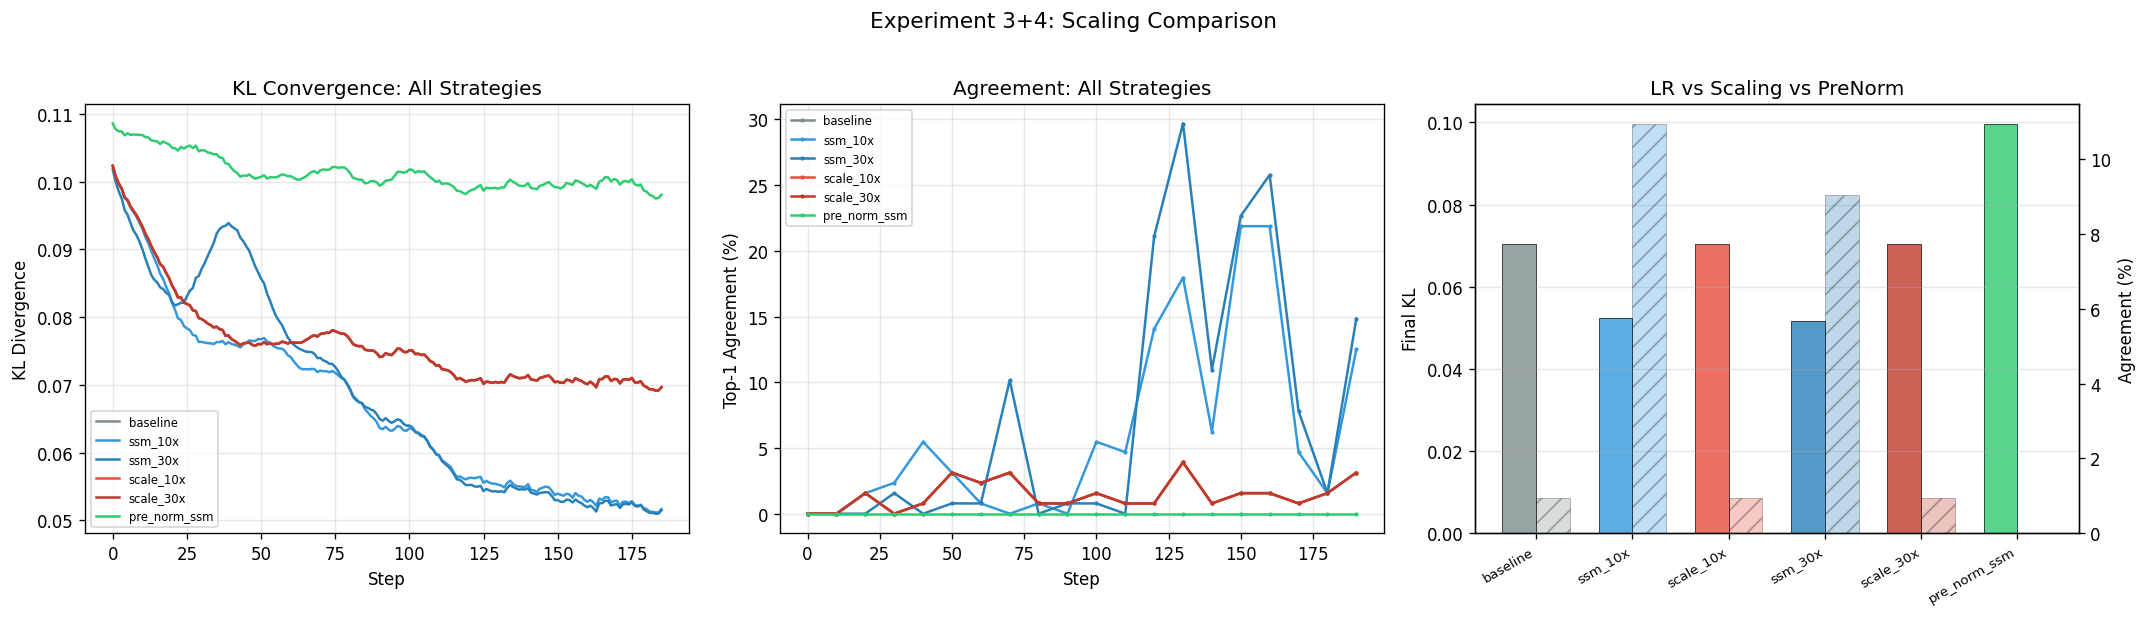

Saved: results/11_scaling_comparison.png


In [7]:
# Combine all strategies for comparison
all_strategies = {}
all_strategies["baseline"] = {
    "kl_history": baseline_kl_history,
    "agree_history": baseline_agree_history,
    "final_kl": final_kl_bl,
    "final_agreement": final_agree_bl,
}
for name in lr_results:
    all_strategies[name] = lr_results[name]
for name in scale_results:
    all_strategies[name] = scale_results[name]
all_strategies["pre_norm_ssm"] = prenorm_result

strategy_colors = {
    "baseline": "#7f8c8d",
    "uniform_3e-4": "#95a5a6",
    "ssm_10x": "#3498db",
    "ssm_30x": "#2980b9",
    "scale_10x": "#e74c3c",
    "scale_30x": "#c0392b",
    "pre_norm_ssm": "#2ecc71",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) KL convergence -- all strategies
ax = axes[0]
for name in ["baseline", "ssm_10x", "ssm_30x", "scale_10x", "scale_30x", "pre_norm_ssm"]:
    ax.plot(smooth(all_strategies[name]["kl_history"]), label=name,
            color=strategy_colors[name], linewidth=1.5)
ax.set_xlabel("Step")
ax.set_ylabel("KL Divergence")
ax.set_title("KL Convergence: All Strategies")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# (b) Agreement -- all strategies
ax = axes[1]
for name in ["baseline", "ssm_10x", "ssm_30x", "scale_10x", "scale_30x", "pre_norm_ssm"]:
    agree = all_strategies[name]["agree_history"]
    ax.plot(range(0, N_STEPS, 10)[:len(agree)], [a*100 for a in agree],
            label=name, color=strategy_colors[name], linewidth=1.5, marker=".", markersize=3)
ax.set_xlabel("Step")
ax.set_ylabel("Top-1 Agreement (%)")
ax.set_title("Agreement: All Strategies")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# (c) LR approach vs scaling approach (paired comparison)
ax = axes[2]
compare_names = ["baseline", "ssm_10x", "scale_10x", "ssm_30x", "scale_30x", "pre_norm_ssm"]
compare_kl = [all_strategies[n]["final_kl"] for n in compare_names]
compare_agree = [all_strategies[n]["final_agreement"]*100 for n in compare_names]
x = np.arange(len(compare_names))
w = 0.35
ax2 = ax.twinx()
bars1 = ax.bar(x - w/2, compare_kl, w, color=[strategy_colors[n] for n in compare_names],
               alpha=0.8, edgecolor="black", linewidth=0.5, label="Final KL")
bars2 = ax2.bar(x + w/2, compare_agree, w, color=[strategy_colors[n] for n in compare_names],
                alpha=0.3, edgecolor="black", linewidth=0.5, hatch="//", label="Agreement")
ax.set_xticks(x)
ax.set_xticklabels(compare_names, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Final KL")
ax2.set_ylabel("Agreement (%)")
ax.set_title("LR vs Scaling vs PreNorm")
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Experiment 3+4: Scaling Comparison", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../results/11_scaling_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: results/11_scaling_comparison.png")

## 7. Summary Comparison Table + JSON Export

For each strategy: final_kl, final_agreement, SSM_grad_norm_mean, MoE_grad_norm_mean, ratio.

In [8]:
# Build summary table
summary_rows = []

# Baseline
summary_rows.append({
    "strategy": "baseline (uniform 3e-4)",
    "final_kl": all_results["baseline"]["final_kl"],
    "final_agreement": all_results["baseline"]["final_agreement"],
    "ssm_grad_mean": all_results["baseline"]["ssm_grad_mean"],
    "moe_grad_mean": all_results["baseline"]["moe_grad_mean"],
    "ratio": all_results["baseline"]["ratio"],
})

# LR strategies (skip uniform since it matches baseline)
for name in ["ssm_10x", "ssm_30x"]:
    r = all_results["lr_strategies"][name]
    summary_rows.append({
        "strategy": f"LR {name}",
        "final_kl": r["final_kl"],
        "final_agreement": r["final_agreement"],
        "ssm_grad_mean": r["ssm_grad_mean"],
        "moe_grad_mean": r["moe_grad_mean"],
        "ratio": r["ratio"],
    })

# Gradient scaling
for name in ["scale_10x", "scale_30x"]:
    r = all_results["gradient_scaling"][name]
    summary_rows.append({
        "strategy": f"Grad {name}",
        "final_kl": r["final_kl"],
        "final_agreement": r["final_agreement"],
        "ssm_grad_mean": r["ssm_grad_mean"],
        "moe_grad_mean": r["moe_grad_mean"],
        "ratio": r["ratio"],
    })

# PreNorm
r = all_results["prenorm_ssm"]
summary_rows.append({
    "strategy": "PreNorm SSM",
    "final_kl": r["final_kl"],
    "final_agreement": r["final_agreement"],
    "ssm_grad_mean": r["ssm_grad_mean"],
    "moe_grad_mean": r["moe_grad_mean"],
    "ratio": r["ratio"],
})

all_results["summary"] = summary_rows

# Print formatted table
print("=" * 95)
print("GRADIENT BALANCE -- SUMMARY COMPARISON")
print("=" * 95)
header = f"{'Strategy':28s} | {'Final KL':>9s} | {'Agree %':>8s} | {'SSM Grad':>10s} | {'MoE Grad':>10s} | {'Ratio':>7s}"
print(header)
print("-" * 95)
for row in summary_rows:
    print(f"{row['strategy']:28s} | {row['final_kl']:9.4f} | {row['final_agreement']*100:7.1f}% | "
          f"{row['ssm_grad_mean']:10.6f} | {row['moe_grad_mean']:10.6f} | {row['ratio']:7.4f}")
print("=" * 95)

# Find best strategy
best = min(summary_rows, key=lambda r: r["final_kl"])
print(f"\nBest strategy by KL: {best['strategy']} (KL={best['final_kl']:.4f})")
best_agree = max(summary_rows, key=lambda r: r["final_agreement"])
print(f"Best strategy by agreement: {best_agree['strategy']} (agree={best_agree['final_agreement']*100:.1f}%)")
closest_ratio = min(summary_rows, key=lambda r: abs(r["ratio"] - 1.0))
print(f"Best gradient balance: {closest_ratio['strategy']} (ratio={closest_ratio['ratio']:.4f})")

# Export
all_results["config"] = {
    "vocab_size": VOCAB_SIZE,
    "seq_len": SEQ_LEN,
    "batch_size": BATCH_SIZE,
    "n_steps": N_STEPS,
    "teacher_d_model": TEACHER_D_MODEL,
    "teacher_layers": TEACHER_LAYERS,
    "teacher_params": t_params,
    "seed": 42,
}

output_path = Path("../results/11_gradient_balance.json")
with open(output_path, "w") as f:
    json.dump(all_results, f, indent=2)

print(f"\nResults saved: {output_path}")
print("Plots saved: results/11_gradient_profiles.png, 11_lr_strategies.png, 11_scaling_comparison.png")

GRADIENT BALANCE -- SUMMARY COMPARISON
Strategy                     |  Final KL |  Agree % |   SSM Grad |   MoE Grad |   Ratio
-----------------------------------------------------------------------------------------------
baseline (uniform 3e-4)      |    0.0703 |     0.9% |   0.002051 |   0.053396 |  0.0384
LR ssm_10x                   |    0.0524 |    10.9% |   0.015072 |   0.024963 |  0.6038
LR ssm_30x                   |    0.0516 |     9.1% |   0.012991 |   0.009604 |  1.3526
Grad scale_10x               |    0.0703 |     0.9% |   0.020509 |   0.053396 |  0.3841
Grad scale_30x               |    0.0703 |     0.9% |   0.061527 |   0.053396 |  1.1523
PreNorm SSM                  |    0.0995 |     0.0% |   0.000878 |   0.008236 |  0.1066

Best strategy by KL: LR ssm_30x (KL=0.0516)
Best strategy by agreement: LR ssm_10x (agree=10.9%)
Best gradient balance: Grad scale_30x (ratio=1.1523)

Results saved: ../results/11_gradient_balance.json
Plots saved: results/11_gradient_profiles.png,